# Lecture 16: Working with Date/Time Data (Time Series)
## One-Step Date Parsing + Indexing
- parse_dates=['col'] + index_col=['col'] together in read_csv() — converts the column
  to a proper datetime type AND sets it as the index, in a single step
- Previously this took two separate steps (pd.to_datetime() then set_index())

In [11]:
import pandas as pd
df = pd.read_csv("../datasets/aapl.csv", parse_dates=['Date'], index_col=['Date'])
df.head(3)


C:\Users\ap504\AppData\Local\Temp\ipykernel_11304\3533912306.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("../datasets/aapl.csv", parse_dates=['Date'], index_col=['Date'])


,Open,High,Low,Close,Volume
Date,,,,,
2017-07-07,142.90,144.75,142.90,144.18,19201712
2017-07-06,143.02,143.50,142.41,142.73,24128782
2017-07-05,143.69,144.79,142.72,144.09,21569557


In [12]:
df.index

DatetimeIndex(['2017-07-07', '2017-07-06', '2017-07-05', '2017-07-03',
               '2017-06-30', '2017-06-29', '2017-06-28', '2017-06-27',
               '2017-06-26', '2017-06-23',
               ...
               '2016-07-22', '2016-07-21', '2016-07-20', '2016-07-19',
               '2016-07-18', '2016-07-15', '2016-07-14', '2016-07-13',
               '2016-07-12', '2016-07-11'],
              dtype='datetime64[ns]', name='Date', length=251, freq=None)

## Partial String Indexing (only works with .loc, on a DatetimeIndex)
- df.loc["2017"]        → entire year (all rows in 2017) → returns a DataFrame
- df.loc["2017-01"]     → entire month (all rows in Jan 2017) → returns a DataFrame
- df.loc["2017-01-05"]  → a single specific day → returns a Series (one row)
- MUST use .loc — without it, Pandas looks for a literal column named "2017-01"
  and throws a KeyError, since it doesn't know this is meant as date-based lookup

In [13]:
df.loc["2017-01"]

,Open,High,Low,Close,Volume
Date,,,,,
2017-01-31,121.15,121.39,120.62,121.35,49200993
2017-01-30,120.93,121.63,120.66,121.63,30377503
2017-01-27,122.14,122.35,121.60,121.95,20562944
2017-01-26,121.67,122.44,121.60,121.94,26337576
2017-01-25,120.42,122.10,120.28,121.88,32586673
2017-01-24,119.55,120.10,119.50,119.97,23211038
2017-01-23,120.00,120.81,119.77,120.08,22050218
2017-01-20,120.45,120.45,119.73,120.00,32597892
2017-01-19,119.40,120.09,119.37,119.78,25597291


In [14]:
df.loc["2017-01"].Close

Date
2017-01-31    121.35
2017-01-30    121.63
2017-01-27    121.95
2017-01-26    121.94
2017-01-25    121.88
2017-01-24    119.97
2017-01-23    120.08
2017-01-20    120.00
2017-01-19    119.78
2017-01-18    119.99
2017-01-17    120.00
2017-01-13    119.04
2017-01-12    119.25
2017-01-11    119.75
2017-01-10    119.11
2017-01-09    118.99
2017-01-06    117.91
2017-01-05    116.61
2017-01-04    116.02
2017-01-03    116.15
Name: Close, dtype: float64

In [15]:
df.loc["2017-01"].Close.mean()

np.float64(119.57000000000001)

In [16]:
df.loc["2017-2-1"]

Open      1.270300e+02
High      1.304900e+02
Low       1.270100e+02
Close     1.287500e+02
Volume    1.119850e+08
Name: 2017-02-01 00:00:00, dtype: float64

## sort_index() — Fixing Chronological Order
- Stock/financial data often comes in reverse order (latest date first)
- sort_index() sorts by the index (dates here) into proper oldest→newest order
- Like any transform, store the result in a NEW variable — sort_index() does not
  modify the original DataFrame unless inplace=True is explicitly passed

In [17]:
new_df = df.sort_index()
new_df.loc["2017-01-01":"2017-01-05"]

,Open,High,Low,Close,Volume
Date,,,,,
2017-01-03,115.80,116.33,114.76,116.15,28781865
2017-01-04,115.85,116.51,115.75,116.02,21118116
2017-01-05,115.92,116.86,115.81,116.61,22193587


## resample() — Time-Based Aggregation
- Groups data by a time period and applies an aggregate function — conceptually the
  same as pd.Grouper(freq=...) used earlier inside pivot_table, but simpler syntax
  when applied directly on a Series/column
- Common frequency codes: 'D' Daily, 'W' Weekly, 'M' Monthly, 'QE' Quarterly (Quarter End), 'Y' Yearly
- resample('freq').mean() → average per period
- resample('freq').sum()  → total per period

In [18]:
new_df.Close.resample('M').mean()

C:\Users\ap504\AppData\Local\Temp\ipykernel_11304\520018020.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  new_df.Close.resample('M').mean()


Date
2016-07-31     99.473333
2016-08-31    107.665217
2016-09-30    110.857143
2016-10-31    115.707143
2016-11-30    110.154286
2016-12-31    114.335714
2017-01-31    119.570000
2017-02-28    133.713684
2017-03-31    140.617826
2017-04-30    142.886842
2017-05-31    152.227727
2017-06-30    147.831364
2017-07-31    143.625000
Freq: ME, Name: Close, dtype: float64

## Visualization with resample()
- %matplotlib inline → makes charts render directly inside the Jupyter notebook
- .resample(...).mean().plot() → line chart (default)
- .resample(...).mean().plot(kind='bar') → bar chart instead

<Axes: xlabel='Date'>

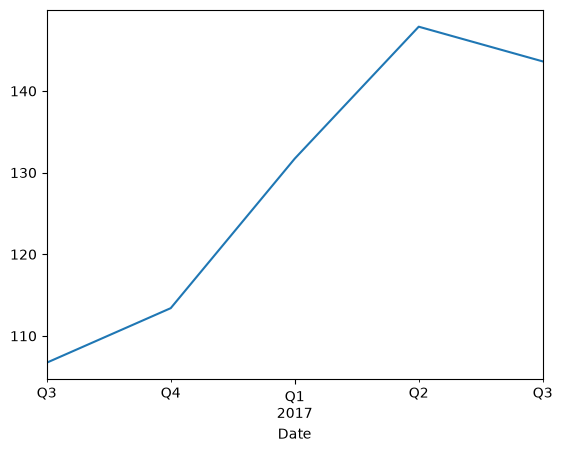

In [19]:
%matplotlib inline
new_df.Close.resample('QE').mean().plot()

<Axes: xlabel='Date'>

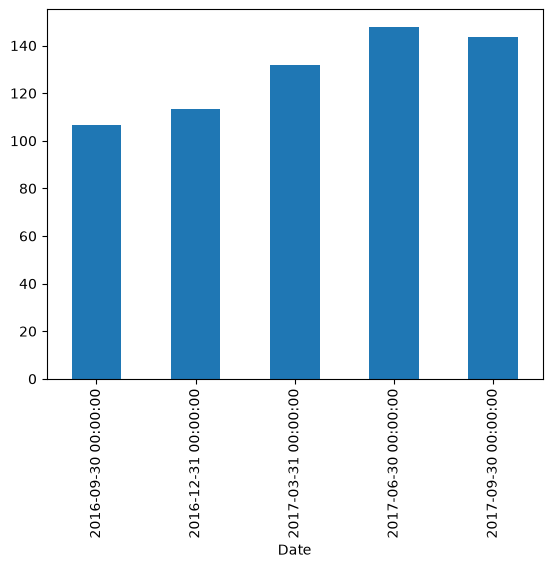

In [20]:
new_df.Close.resample('QE').mean().plot(kind='bar')